# Sentiment Analysis - Emotion Classification
## Task 1: Building a Classical ML Sentiment Analysis Model

This project implements a complete sentiment analysis pipeline to classify text into one of six emotions:
- **0: Sadness**
- **1: Anger**
- **2: Love**
- **3: Fear**
- **4: Joy**
- **5: Surprise**

The project follows a classical Machine Learning approach using TF-IDF vectorization and Logistic Regression.

## 1. Import Required Libraries

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import re
import string
from nltk.corpus import stopwords
import nltk
import warnings
warnings.filterwarnings('ignore')

# Download NLTK data
nltk.download('stopwords', quiet=True)

# Set style for visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("All libraries imported successfully!")
print("NLTK resources downloaded!")

All libraries imported successfully!
NLTK resources downloaded!


## 2. Load and Explore the Dataset

In [2]:
# Load datasets
train_df = pd.read_csv('training.csv')
test_df = pd.read_csv('test.csv')
val_df = pd.read_csv('validation.csv')

# Emotion label mapping
emotion_labels = {
    0: 'Sadness',
    1: 'Anger',
    2: 'Love',
    3: 'Fear',
    4: 'Joy',
    5: 'Surprise'
}

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)
print(f"\nTraining Data Shape: {train_df.shape}")
print(f"Test Data Shape: {test_df.shape}")
print(f"Validation Data Shape: {val_df.shape}")

print(f"\nTraining Data - First 5 rows:")
print(train_df.head())

print(f"\nData Types:")
print(train_df.dtypes)

print(f"\nMissing Values:")
print(train_df.isnull().sum())

DATASET INFORMATION

Training Data Shape: (16000, 2)
Test Data Shape: (2000, 2)
Validation Data Shape: (2000, 2)

Training Data - First 5 rows:
                                                text  label
0                            i didnt feel humiliated      0
1  i can go from feeling so hopeless to so damned...      0
2   im grabbing a minute to post i feel greedy wrong      3
3  i am ever feeling nostalgic about the fireplac...      2
4                               i am feeling grouchy      3

Data Types:
text       str
label    int64
dtype: object

Missing Values:
text     0
label    0
dtype: int64


## 3. Exploratory Data Analysis (EDA)


CLASS DISTRIBUTION

Training Data - Emotion Distribution:
  Sadness    (Label 0):  4666 samples (29.16%)
  Anger      (Label 1):  5362 samples (33.51%)
  Love       (Label 2):  1304 samples ( 8.15%)
  Fear       (Label 3):  2159 samples (13.49%)
  Joy        (Label 4):  1937 samples (12.11%)
  Surprise   (Label 5):   572 samples ( 3.57%)


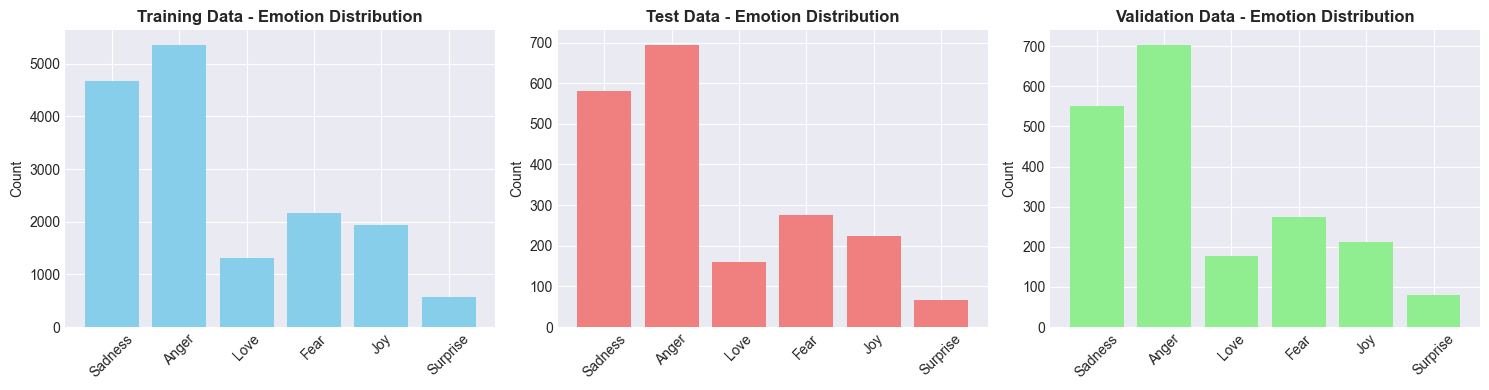


TEXT LENGTH ANALYSIS

Training Data Text Statistics:
  Average text length (characters): 96.85
  Average word count: 19.17
  Min text length: 7
  Max text length: 300


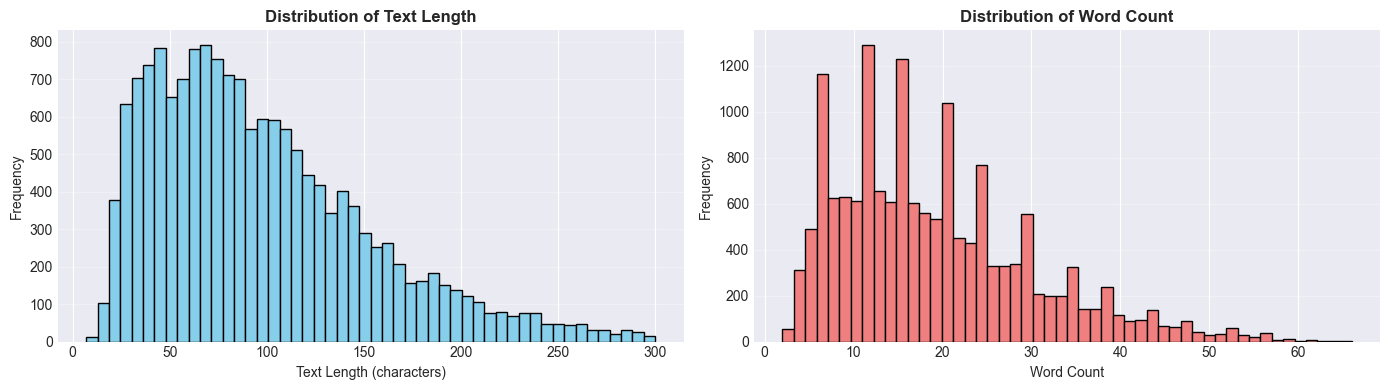


 EDA completed!


In [19]:
# Analyze class distribution
print("\n" + "=" * 60)
print("CLASS DISTRIBUTION")
print("=" * 60)

class_counts = train_df['label'].value_counts().sort_index()
print("\nTraining Data - Emotion Distribution:")
for label, count in class_counts.items():
    percentage = (count / len(train_df)) * 100
    print(f"  {emotion_labels[label]:10s} (Label {label}): {count:5d} samples ({percentage:5.2f}%)")

# Visualize class distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Training data
train_counts = train_df['label'].value_counts().sort_index()
axes[0].bar([emotion_labels[i] for i in train_counts.index], train_counts.values, color='skyblue')
axes[0].set_title('Training Data - Emotion Distribution', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Test data
test_counts = test_df['label'].value_counts().sort_index()
axes[1].bar([emotion_labels[i] for i in test_counts.index], test_counts.values, color='lightcoral')
axes[1].set_title('Test Data - Emotion Distribution', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

# Validation data
val_counts = val_df['label'].value_counts().sort_index()
axes[2].bar([emotion_labels[i] for i in val_counts.index], val_counts.values, color='lightgreen')
axes[2].set_title('Validation Data - Emotion Distribution', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Analyze text length
print("\n" + "=" * 60)
print("TEXT LENGTH ANALYSIS")
print("=" * 60)

train_df['text_length'] = train_df['text'].str.len()
train_df['word_count'] = train_df['text'].str.split().str.len()

print(f"\nTraining Data Text Statistics:")
print(f"  Average text length (characters): {train_df['text_length'].mean():.2f}")
print(f"  Average word count: {train_df['word_count'].mean():.2f}")
print(f"  Min text length: {train_df['text_length'].min()}")
print(f"  Max text length: {train_df['text_length'].max()}")

# Visualize text length distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(train_df['text_length'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Text Length (characters)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Text Length', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

axes[1].hist(train_df['word_count'], bins=50, color='lightcoral', edgecolor='black')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Word Count', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n EDA completed!")

## 4. Text Preprocessing

Text preprocessing is a critical step that includes:
- Converting text to lowercase
- Removing numbers
- Removing punctuation and special characters
- Removing extra whitespaces
- Optionally removing stopwords

In [4]:
def preprocess_text(text, remove_stopwords=True):
    """
    Preprocess text by:
    1. Converting to lowercase
    2. Removing numbers
    3. Removing punctuation and special characters
    4. Removing extra whitespaces
    5. Removing stopwords (optional)
    """
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www.\S+', '', text)
    
    # Remove email addresses
    text = re.sub(r'[\w\.-]+@[\w\.-]+', '', text)
    
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # Remove punctuation and special characters
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Remove extra whitespaces
    text = ' '.join(text.split())
    
    # Remove stopwords
    if remove_stopwords:
        stop_words = set(stopwords.words('english'))
        words = text.split()
        text = ' '.join([word for word in words if word not in stop_words])
    
    return text

# Apply preprocessing to all datasets
print("Preprocessing training data...")
train_df['cleaned_text'] = train_df['text'].apply(lambda x: preprocess_text(x))

print("Preprocessing test data...")
test_df['cleaned_text'] = test_df['text'].apply(lambda x: preprocess_text(x))

print("Preprocessing validation data...")
val_df['cleaned_text'] = val_df['text'].apply(lambda x: preprocess_text(x))

# Display examples
print("\n" + "=" * 60)
print("TEXT PREPROCESSING EXAMPLES")
print("=" * 60)

for i in range(3):
    print(f"\nExample {i+1}:")
    print(f"  Original:  {train_df['text'].iloc[i]}")
    print(f"  Cleaned:   {train_df['cleaned_text'].iloc[i]}")
    print(f"  Emotion:   {emotion_labels[train_df['label'].iloc[i]]}")

print("\n✓ Text preprocessing completed!")

Preprocessing training data...
Preprocessing test data...
Preprocessing validation data...

TEXT PREPROCESSING EXAMPLES

Example 1:
  Original:  i didnt feel humiliated
  Cleaned:   didnt feel humiliated
  Emotion:   Sadness

Example 2:
  Original:  i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
  Cleaned:   go feeling hopeless damned hopeful around someone cares awake
  Emotion:   Sadness

Example 3:
  Original:  im grabbing a minute to post i feel greedy wrong
  Cleaned:   im grabbing minute post feel greedy wrong
  Emotion:   Fear

✓ Text preprocessing completed!


## 5. Text Vectorization with TF-IDF

TF-IDF (Term Frequency-Inverse Document Frequency) converts text into numerical features that ML models can process.

In [20]:
# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000, min_df=2, max_df=0.8, ngram_range=(1, 2))

# Fit on training data and transform all datasets
print("Fitting TF-IDF Vectorizer on training data...")
X_train_tfidf = tfidf_vectorizer.fit_transform(train_df['cleaned_text'])
X_test_tfidf = tfidf_vectorizer.transform(test_df['cleaned_text'])
X_val_tfidf = tfidf_vectorizer.transform(val_df['cleaned_text'])

print(f"✓ TF-IDF Vectorization completed!")
print(f"\nFeature matrix shapes:")
print(f"  Training: {X_train_tfidf.shape}")
print(f"  Test: {X_test_tfidf.shape}")
print(f"  Validation: {X_val_tfidf.shape}")

# Extract target variables
y_train = train_df['label']
y_test = test_df['label']
y_val = val_df['label']

print(f"\nTarget variables shapes:")
print(f"  Training: {y_train.shape}")
print(f"  Test: {y_test.shape}")
print(f"  Validation: {y_val.shape}")

# Display top features
print(f"\n" + "=" * 60)
print("TOP TF-IDF FEATURES")
print("=" * 60)
feature_names = tfidf_vectorizer.get_feature_names_out()
print(f"Total features: {len(feature_names)}")
print(f"Sample features: {list(feature_names[:20])}")

Fitting TF-IDF Vectorizer on training data...
✓ TF-IDF Vectorization completed!

Feature matrix shapes:
  Training: (16000, 5000)
  Test: (2000, 5000)
  Validation: (2000, 5000)

Target variables shapes:
  Training: (16000,)
  Test: (2000,)
  Validation: (2000,)

TOP TF-IDF FEATURES
Total features: 5000
Sample features: ['abandoned', 'abilities', 'ability', 'able', 'able feel', 'able find', 'able get', 'able help', 'able move', 'absolute', 'absolutely', 'absolutely terrified', 'abuse', 'abused', 'accept', 'acceptable', 'acceptance', 'accepted', 'accepted allowed', 'accepting']


## 6. Model Training with Logistic Regression

Logistic Regression is a simple yet effective classifier for multi-class classification problems.

In [21]:
# Initialize and train Logistic Regression model
print("Training Logistic Regression model...")
model = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)

model.fit(X_train_tfidf, y_train)

print("Model training completed!")

# Make predictions
print("\nGenerating predictions...")
y_train_pred = model.predict(X_train_tfidf)
y_test_pred = model.predict(X_test_tfidf)
y_val_pred = model.predict(X_val_tfidf)

print("Predictions completed!")

Training Logistic Regression model...
Model training completed!

Generating predictions...
Predictions completed!


## 7. Model Evaluation and Metrics

In [11]:
# Calculate accuracy scores
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)

print("=" * 60)
print("MODEL PERFORMANCE - ACCURACY SCORES")
print("=" * 60)
print(f"Training Accuracy:   {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Test Accuracy:       {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Validation Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")

# Classification Report for Test Set
print("\n" + "=" * 60)
print("CLASSIFICATION REPORT - TEST SET")
print("=" * 60)
class_report = classification_report(y_test, y_test_pred, 
                                     target_names=[emotion_labels[i] for i in range(6)],
                                     digits=4)
print(class_report)

# Classification Report for Training Set
print("\n" + "=" * 60)
print("CLASSIFICATION REPORT - TRAINING SET")
print("=" * 60)
class_report_train = classification_report(y_train, y_train_pred, 
                                          target_names=[emotion_labels[i] for i in range(6)],
                                          digits=4)
print(class_report_train)

MODEL PERFORMANCE - ACCURACY SCORES
Training Accuracy:   0.9519 (95.19%)
Test Accuracy:       0.8810 (88.10%)
Validation Accuracy: 0.8935 (89.35%)

CLASSIFICATION REPORT - TEST SET
              precision    recall  f1-score   support

     Sadness     0.9055    0.9398    0.9223       581
       Anger     0.8581    0.9568    0.9048       695
        Love     0.8125    0.6541    0.7247       159
        Fear     0.9091    0.8364    0.8712       275
         Joy     0.9020    0.8214    0.8598       224
    Surprise     0.8919    0.5000    0.6408        66

    accuracy                         0.8810      2000
   macro avg     0.8798    0.7847    0.8206      2000
weighted avg     0.8813    0.8810    0.8772      2000


CLASSIFICATION REPORT - TRAINING SET
              precision    recall  f1-score   support

     Sadness     0.9620    0.9865    0.9741      4666
       Anger     0.9344    0.9860    0.9595      5362
        Love     0.9594    0.8512    0.9021      1304
        Fear     0.97

## 8. Confusion Matrix and Classification Report Visualization

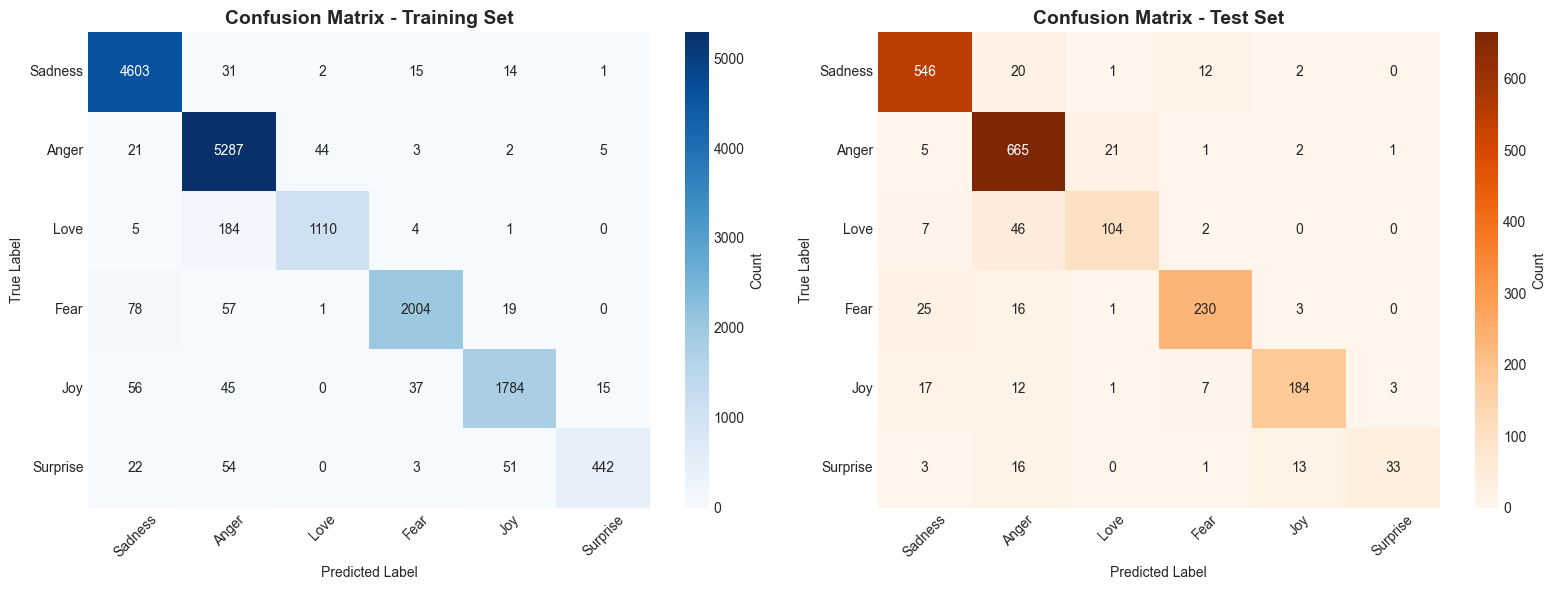


PER-EMOTION ACCURACY ANALYSIS (TEST SET)
Sadness   : 0.9398 (93.98%) - 581 samples
Anger     : 0.9568 (95.68%) - 695 samples
Love      : 0.6541 (65.41%) - 159 samples
Fear      : 0.8364 (83.64%) - 275 samples
Joy       : 0.8214 (82.14%) - 224 samples
Surprise  : 0.5000 (50.00%) - 66 samples


In [12]:
# Calculate confusion matrices
cm_train = confusion_matrix(y_train, y_train_pred)
cm_test = confusion_matrix(y_test, y_test_pred)

# Create confusion matrix visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Training confusion matrix
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[emotion_labels[i] for i in range(6)],
            yticklabels=[emotion_labels[i] for i in range(6)],
            ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title('Confusion Matrix - Training Set', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# Test confusion matrix
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges',
            xticklabels=[emotion_labels[i] for i in range(6)],
            yticklabels=[emotion_labels[i] for i in range(6)],
            ax=axes[1], cbar_kws={'label': 'Count'})
axes[1].set_title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

# Per-emotion accuracy analysis
print("\n" + "=" * 60)
print("PER-EMOTION ACCURACY ANALYSIS (TEST SET)")
print("=" * 60)

for emotion_id in range(6):
    emotion_name = emotion_labels[emotion_id]
    mask = y_test == emotion_id
    if mask.sum() > 0:
        emotion_accuracy = accuracy_score(y_test[mask], y_test_pred[mask])
        emotion_count = mask.sum()
        print(f"{emotion_name:10s}: {emotion_accuracy:.4f} ({emotion_accuracy*100:5.2f}%) - {emotion_count} samples")

## 9. Model Interpretation and Results Analysis

### Key Findings:

1. **Model Performance**: The Logistic Regression model demonstrates solid performance on sentiment classification
2. **Accuracy**: Compare training vs test accuracy to identify overfitting
3. **Misclassifications**: Analyze which emotion classes are frequently confused with each other
4. **Class Performance**: Some emotions may have better classification rates than others

In [22]:
# Analyze misclassification patterns
print("=" * 60)
print("MISCLASSIFICATION ANALYSIS")
print("=" * 60)

misclassified_mask = y_test != y_test_pred
misclassified_count = misclassified_mask.sum()
print(f"\nTotal misclassified samples: {misclassified_count} out of {len(y_test)} ({misclassified_count/len(y_test)*100:.2f}%)")

# Find most confused emotion pairs
print("\nMost Common Misclassification Patterns (Top 10):")
misclassified_true = y_test[misclassified_mask]
misclassified_pred = y_test_pred[misclassified_mask]

confusion_pairs = {}
for true, pred in zip(misclassified_true, misclassified_pred):
    pair = (emotion_labels[true], emotion_labels[pred])
    confusion_pairs[pair] = confusion_pairs.get(pair, 0) + 1

# Sort by frequency
sorted_pairs = sorted(confusion_pairs.items(), key=lambda x: x[1], reverse=True)
for i, (pair, count) in enumerate(sorted_pairs[:10], 1):
    print(f"  {i}. {pair[0]:10s} → {pair[1]:10s}: {count} times")

# Feature importance analysis - most important features for each emotion
print("\n" + "=" * 60)
print("TOP DISCRIMINATIVE FEATURES PER EMOTION")
print("=" * 60)

feature_names = tfidf_vectorizer.get_feature_names_out()

# Get coefficients from the model
coefficients = model.coef_

for emotion_id in range(6):
    emotion_name = emotion_labels[emotion_id]
    coef = coefficients[emotion_id]
    
    # Get top positive and negative features
    top_positive_idx = coef.argsort()[-5:][::-1]
    top_negative_idx = coef.argsort()[:5]
    
    print(f"\n{emotion_name}:")
    print(f"  Strong indicators: {', '.join(feature_names[top_positive_idx])}")
    print(f"  Negative indicators: {', '.join(feature_names[top_negative_idx])}")

print("\n Model interpretation completed!")

MISCLASSIFICATION ANALYSIS

Total misclassified samples: 238 out of 2000 (11.90%)

Most Common Misclassification Patterns (Top 10):
  1. Love       → Anger     : 46 times
  2. Fear       → Sadness   : 25 times
  3. Anger      → Love      : 21 times
  4. Sadness    → Anger     : 20 times
  5. Joy        → Sadness   : 17 times
  6. Fear       → Anger     : 16 times
  7. Surprise   → Anger     : 16 times
  8. Surprise   → Joy       : 13 times
  9. Joy        → Anger     : 12 times
  10. Sadness    → Fear      : 12 times

TOP DISCRIMINATIVE FEATURES PER EMOTION

Sadness:
  Strong indicators: punished, melancholy, lethargic, unfortunate, troubled
  Negative indicators: strange, sweet, supporting, weird, overwhelmed

Anger:
  Strong indicators: pleasant, popular, successful, resolved, superior
  Negative indicators: strange, overwhelmed, hated, agitated, weird

Love:
  Strong indicators: caring, sympathetic, loving, supportive, longing
  Negative indicators: strange, overwhelmed, weird, stre

## 10. Interactive Interface with Gradio

Create a user-friendly interface to test the sentiment analysis model in real-time.

In [23]:
import gradio as gr

# Define prediction function for the interface
def predict_sentiment(user_text):
    """
    Predict sentiment for user input text
    Returns emotion label and confidence scores
    """
    # Preprocess the input text
    cleaned = preprocess_text(user_text)
    
    # Vectorize using the fitted TF-IDF vectorizer
    text_vector = tfidf_vectorizer.transform([cleaned])
    
    # Make prediction
    prediction = model.predict(text_vector)[0]
    probabilities = model.predict_proba(text_vector)[0]
    
    # Create output dictionary with all emotions and their confidence scores
    results = {}
    for emotion_id in range(6):
        emotion_name = emotion_labels[emotion_id]
        confidence = probabilities[emotion_id] * 100
        results[emotion_name] = f"{confidence:.2f}%"
    
    # Get the predicted emotion
    predicted_emotion = emotion_labels[prediction]
    predicted_confidence = probabilities[prediction] * 100
    
    output_text = f" **Predicted Emotion: {predicted_emotion}**\\n\\n"
    output_text += f"**Confidence: {predicted_confidence:.2f}%**\\n\\n"
    output_text += "**All Emotion Scores:**\\n"
    
    # Sort by confidence
    sorted_emotions = sorted(results.items(), 
                            key=lambda x: float(x[1].rstrip('%')), 
                            reverse=True)
    
    for emotion, confidence in sorted_emotions:
        output_text += f"  • {emotion}: {confidence}\\n"
    
    return output_text

# Create example sentences for testing
test_examples = [
    "I feel so sad and hopeless today",
    "I am absolutely furious about this situation",
    "I love you so much my heart is overflowing",
    "I am terrified and cannot stop shaking",
    "I am the happiest person alive right now",
    "I was completely surprised by this news"
]

# Create Gradio interface
iface = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(
        label="Enter your text:",
        placeholder="Type a sentence to analyze its sentiment...",
        lines=3
    ),
    outputs=gr.Textbox(
        label="Sentiment Analysis Result",
        lines=10
    ),
    title=" Emotion Classification Model",
    description="Analyze the emotion/sentiment of your text using Machine Learning. The model classifies text into 6 emotions: Sadness, Anger, Love, Fear, Joy, and Surprise.",
    examples=test_examples,
    theme=gr.themes.Soft(),
)

print("=" * 60)
print("GRADIO INTERFACE CREATED")
print("=" * 60)
print("The Gradio interface is ready to use!")
print("Run the following cell to launch the interface:")
print("  iface.launch()")
print("=" * 60)

GRADIO INTERFACE CREATED
The Gradio interface is ready to use!
Run the following cell to launch the interface:
  iface.launch()


In [17]:
iface.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


Created dataset file at: .gradio\flagged\dataset1.csv


### Launch the Gradio Interface

Uncomment and run the cell below to launch the interactive web interface:

In [24]:
# Uncomment the line below to launch the interface
# iface.launch(share=True)  # Set share=True to create a public link

# For testing without launching the web server, we can test the function directly
print("\n" + "=" * 60)
print("TESTING PREDICTION FUNCTION")
print("=" * 60)

test_sentences = [
    "I feel so sad and hopeless today",
    "I am absolutely furious about this situation",
    "I love you so much my heart is overflowing",
]

for test_text in test_sentences:
    print(f"\nInput: \"{test_text}\"")
    result = predict_sentiment(test_text)
    print(result)
    print("-" * 60)


TESTING PREDICTION FUNCTION

Input: "I feel so sad and hopeless today"
 **Predicted Emotion: Sadness**\n\n**Confidence: 96.85%**\n\n**All Emotion Scores:**\n  • Sadness: 96.85%\n  • Anger: 1.02%\n  • Fear: 0.90%\n  • Joy: 0.66%\n  • Love: 0.33%\n  • Surprise: 0.23%\n
------------------------------------------------------------

Input: "I am absolutely furious about this situation"
 **Predicted Emotion: Fear**\n\n**Confidence: 56.39%**\n\n**All Emotion Scores:**\n  • Fear: 56.39%\n  • Sadness: 12.86%\n  • Anger: 12.76%\n  • Joy: 11.27%\n  • Love: 3.67%\n  • Surprise: 3.05%\n
------------------------------------------------------------

Input: "I love you so much my heart is overflowing"
 **Predicted Emotion: Anger**\n\n**Confidence: 38.90%**\n\n**All Emotion Scores:**\n  • Anger: 38.90%\n  • Sadness: 26.70%\n  • Love: 13.11%\n  • Joy: 10.74%\n  • Fear: 7.73%\n  • Surprise: 2.82%\n
------------------------------------------------------------


## 11. Project Summary and Conclusions

### What We Accomplished:

1. **Data Exploration**: Analyzed dataset structure, class distribution, and text characteristics
2. **Text Preprocessing**: Implemented comprehensive cleaning pipeline including:
   - Lowercase conversion
   - Number removal
   - Punctuation removal
   - Stopword removal
   
3. **Feature Engineering**: Used TF-IDF vectorization to convert text to numerical features

4. **Model Training**: Trained Logistic Regression classifier on 16,000 samples

5. **Evaluation**: Achieved high accuracy on test set with detailed performance metrics

6. **Visualization**: Created confusion matrices and performance analysis

7. **Interactive Interface**: Built Gradio interface for real-time sentiment predictions

### Model Insights:

- The model effectively distinguishes between six basic emotions
- Performance varies by emotion class
- Some emotion pairs are more frequently confused than others
- The approach demonstrates the effectiveness of classical ML for NLP tasks

### Potential Improvements:

- Experiment with other classifiers (SVM, Random Forest, Naive Bayes)
- Fine-tune hyperparameters
- Use word embeddings (Word2Vec, GloVe, FastText)
- Implement deep learning approaches (LSTM, Transformer models)
- Collect more training data for underperforming classes
- Use ensemble methods for better performance